# Demonstration Plotting Method On Observables for Output Analysis/Visualisation

In this demonstration we will run a refinement and then focus on interrogating the results. First we need to run the refinement.

In [2]:
# Requirements for interative plots. 
# Run in terminal: pip install ipywidgets; pip install ipympl

# Imports used for this tutorial
import numpy as np
import os
from MDMC.control import Control
from MDMC.MD import Atom, Dispersion, LennardJones, Simulation, Universe

import matplotlib.pyplot as plt

# Build universe with density 0.0176 atoms per AA^-3
density = 0.0176
universe = Universe(dimensions=23.0668)
Ar = Atom('Ar', charge=0., mass=36.0)
# Calculating number of Ar atoms needed to obtain density
n_ar_atoms = int(density * np.product(universe.dimensions))
universe.fill(Ar, num_struc_units=(n_ar_atoms))

Ar_dispersion = Dispersion(universe,
                           (Ar.atom_type, Ar.atom_type),
                           cutoff=8.,
                           function=LennardJones(epsilon=1.3, sigma=3.0))

simulation = Simulation(universe,
                        engine="lammps",
                        time_step=10.18893,
                        temperature=120.,
                        traj_step=15)
simulation.minimize(n_steps=5000)
simulation.run(n_steps=10000, equilibration=True)

exp_datasets = [{'file_name':'../doc/tutorials/data/Well_s_q_omega_Ar_data.xml',
                 'type':'SQw',
                 'reader':'xml_SQw',
                 'weight':1.,
                 'auto_scale':True,
                 'resolution':800}]

fit_parameters = universe.parameters
fit_parameters['sigma'].constraints = [2.8,3.8]
fit_parameters['epsilon'].constraints = [0.6, 1.4]

Universe created with:
Dimensions [23.07 23.07 23.07]
LAMMPS (29 Sep 2021 - Update 3)
OMP_NUM_THREADS environment is not set. Defaulting to 1 thread. (src/comm.cpp:98)
  using 1 OpenMP thread(s) per MPI task
LAMMPS output is captured by PyLammps wrapper
LAMMPS (29 Sep 2021 - Update 3)
OMP_NUM_THREADS environment is not set. Defaulting to 1 thread. (src/comm.cpp:98)
  using 1 OpenMP thread(s) per MPI task
LAMMPS output is captured by PyLammps wrapper
Total wall time: 0:00:00
Simulation created with lammps engine and settings:
  temperature  120.0



In [3]:
control = Control(simulation=simulation,
                  exp_datasets=exp_datasets,
                  fit_parameters=fit_parameters,
                  minimizer_type="GPO",
                  reset_config=True,
                  MD_steps=12000, 
                  equilibration_steps=6000)
control.refine(n_steps=22)

Control created with:
- Attributes                              -
  Minimizer                             GPO
  FoM type               ChiSquaredExpError
  Number of observables                   1
  Number of parameters                    2

Step         FoM epsilon (#5)   sigma (#6)
   0       608.1          1.3            3
   1       85.48        1.035        3.532
   2       384.2        1.075        2.905
   3       402.2       0.9356        3.782
   4       66.34        1.396         3.47
   5         288       0.7189        2.876
   6       54.58       0.9139        3.198
   7       175.6       0.8076        3.693
   8       68.12       0.6141        3.271
   9       871.6        1.174        2.812
  10       15.77       0.9896        3.336
  11       347.3        1.218        2.966
  12       185.8        0.747        3.001
  13        51.8       0.7752        3.566
  14       353.9        1.141        3.713
  15       70.93        0.665        3.619
  16       287.9        1.

Look at the liklihood of the parameter values across the range of possible parameter values using a built-in helper method

Parameter means = [1.0630286  3.33773965], Parameter errors = [0.02009789 0.00791941]


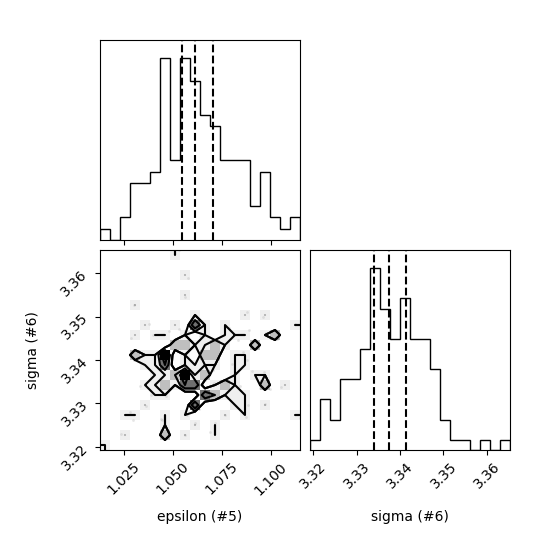

In [24]:
control.plot_results();

The `S(Q,w)` data is contained in the `Control` object used for the refinement. The `ObservablePair` contains both the experimentally measured `S(Q,w)` as well as the one calculated from the last MD simulation's `Trajectory`. 

In [5]:
# Generate Observable Pair for Analysis
obs_pair = control.observable_pairs[0]

Plot the Experimental and Simulated Observables together.

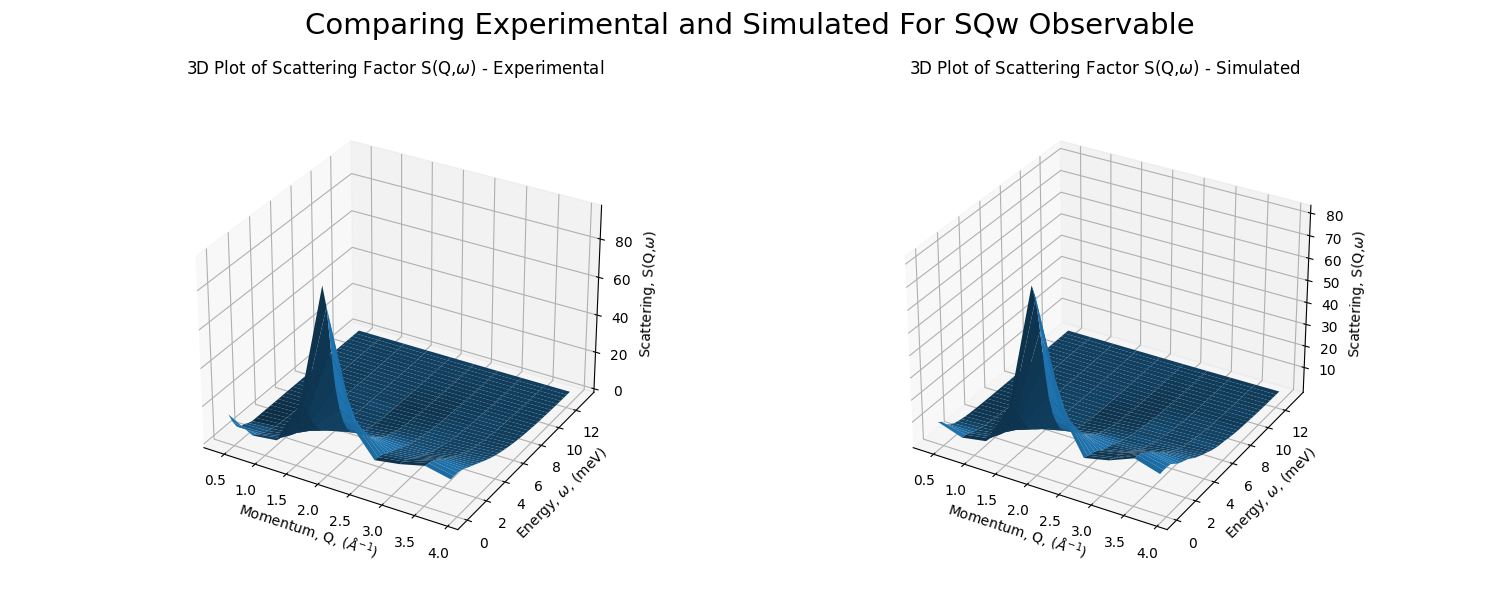

In [15]:
# Compare Experimental and Simulated Observables Side by side:
obs_pair.plot()

Plot using the heatmap option we can can plot the Experimental and Final Trajectories as a heatmap side by side.

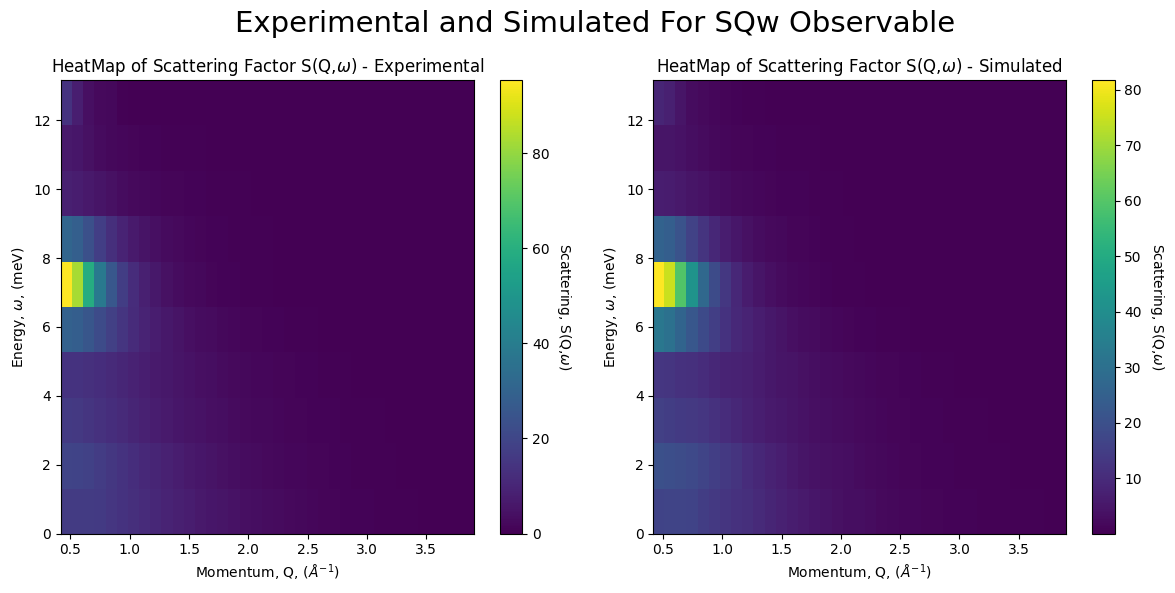

In [7]:
# Compare Experimental and Simulated Observable Via Heatmap
obs_pair.plot(plot_type='heatmap')

Below using the slider option we can look at S(Q,w) as a function of Q from both the experimental data and the final trajectory. A slider can be used to change w. Note that depending on the optimisation procedure used the final trajectory might not correspond to the most optimal point in the refinable parameter space.

In [14]:
# depending on exactly how/where this notebook is run the following widgets command for creating interactive plots might need changing
# Allow plots to be interactive
%matplotlib widget

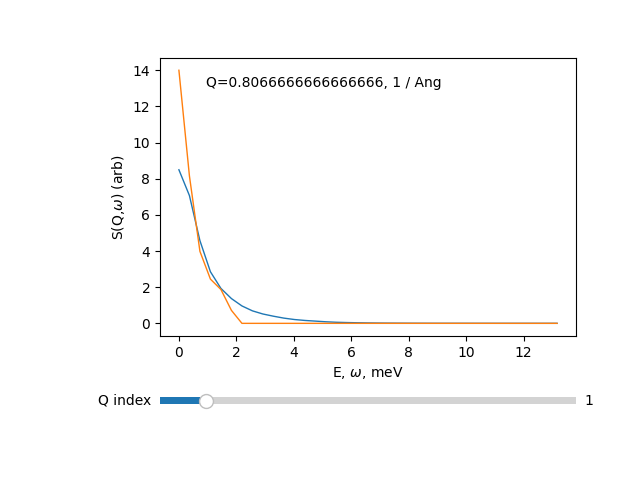

In [17]:
# Compare Experimental and Simulated Via 2D Slider Plot
obs_pair.plot(plot_type='slider')


The residual of the experimental data and final trajectory is the difference between them, the propagrated error is also computed. We can create a new observable for residual and apply the same plotting capabilities to it. 

  plt.tight_layout()



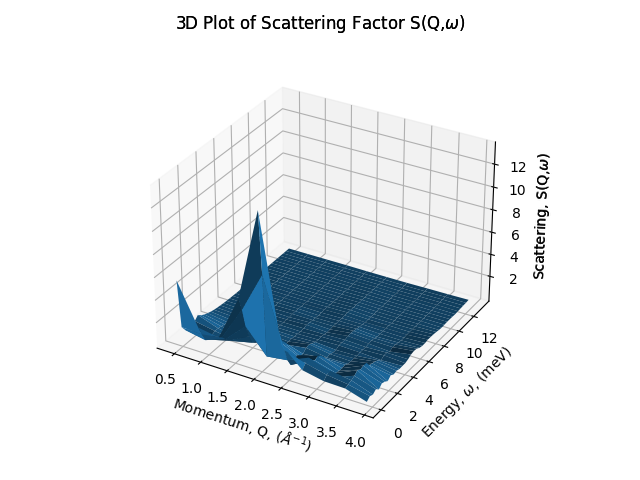

In [18]:
# Create a new Residual observable from Observable pair
obs_pair_residual= obs_pair.residual

# Close previous figure
plt.close(plt.gcf())

# Plot of Residual with independent variables as the Domain.
obs_pair_residual.plot()

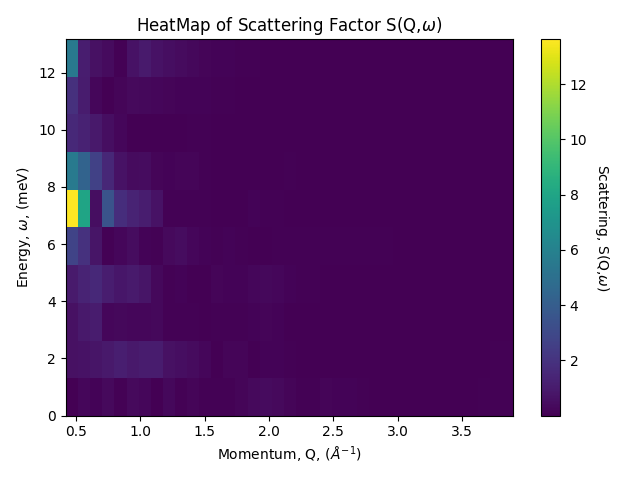

In [19]:
# Close previous figure
plt.close(plt.gcf())

# Heatmap of Residual with independent variables as the Domain.
obs_pair_residual.plot(plot_type='heatmap')

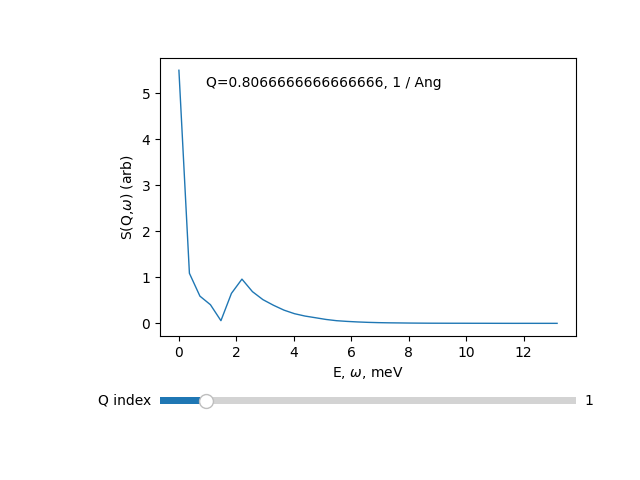

In [20]:
# Close previous figure
plt.close(plt.gcf())

# Slider Plot of the Residual
obs_pair_residual.plot(plot_type='slider')

This is an example of how one could plot the PairDistributionFunction (`PDF`) if that was used as the type of `Observable` to refine. We can calculate the `PDF` from the last `Trajectory` of the refinement above (might not correspond to the most optimal place in parameter space) or we can also import a previously calculated/measured `PDF`.

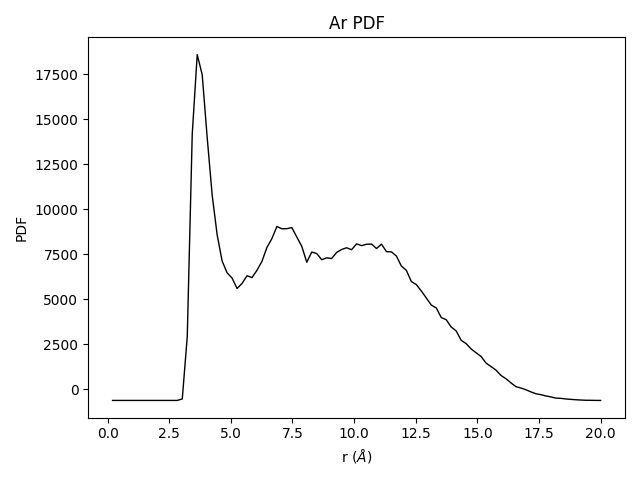

In [21]:
from MDMC.trajectory_analysis.observables.obs_factory import ObservableFactory

PDF_sim=ObservableFactory.create_observable('PDF')
# extract the most recent trajectory from the refinement
traj=control.simulation.trajectory
# set the Universe of the trajectory for the correct dimensions of the MD box
traj.universe=control.simulation.universe
# set the distance points at which to calculate the PDF and then calculate PDF
PDF_sim.r=np.linspace(0, 20, 100)
PDF_sim.calculate_from_MD(traj)

# Close previous figure
plt.close(plt.gcf())

# Plot the PDF observable
PDF_sim.plot(title='Ar PDF')

Below is another example of plotting a `PDF` and partial pairs but this time the data is imported from a previous calculation (using NMOLDYN on a water trajetory to be precise). A paramter minium_R for can be used to allow users to specify a minimum radius to be included in the plot.

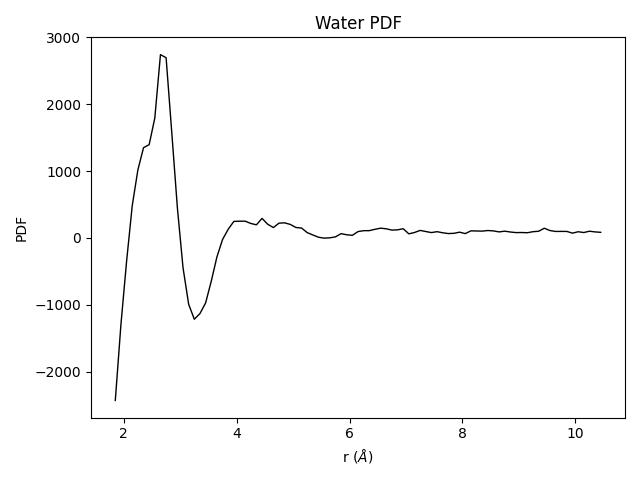

In [22]:
#import the data
obs=ObservableFactory.create_observable('PDF')
obs.read_from_file(reader='netCDFPDF', file_name='../tests/test_data/calculated_observables/nMOLDYN_PDF_water.nc')

# Close previous figure
plt.close(plt.gcf())

# Plot Set Minimum Radius and plot pdf observable
obs.plot(title='Water PDF',minimum_R=1.9)
